In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import json

In [2]:
with open("congress_network_data.json", "r") as f:
    data = json.load(f)

# The JSON file contains one dictionary inside a list
data = data[0]

username_list = data["usernameList"]

print("Number of usernames:", len(username_list))

Number of usernames: 475


In [3]:
G = nx.DiGraph()

with open("congress.edgelist", "r") as f:
    for line in f:
        parts = line.strip().split()

        source = parts[0]
        target = parts[1]
        weight = float(parts[3].rstrip("}"))

        G.add_edge(source, target, weight=weight)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 475
Number of edges: 13289


In [4]:
list(G.edges(data=True))[:10]

[('0', '4', {'weight': 0.002105263157894737}),
 ('0', '12', {'weight': 0.002105263157894737}),
 ('0', '18', {'weight': 0.002105263157894737}),
 ('0', '25', {'weight': 0.004210526315789474}),
 ('0', '30', {'weight': 0.002105263157894737}),
 ('0', '46', {'weight': 0.00631578947368421}),
 ('0', '55', {'weight': 0.002105263157894737}),
 ('0', '58', {'weight': 0.002105263157894737}),
 ('0', '59', {'weight': 0.004210526315789474}),
 ('0', '74', {'weight': 0.002105263157894737})]

In [5]:
in_degree = dict(G.in_degree(weight="weight"))
out_degree = dict(G.out_degree(weight="weight"))

top_in = sorted(
    in_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

for node, score in top_in:
    print(node, score)

322 1.6482815405103295
269 0.9654453416856845
389 0.951852893070543
208 0.8302262681069116
147 0.814184782675911
335 0.7281352156608094
192 0.7110093437797491
113 0.6385432907233617
111 0.6372200579216238
303 0.6327016280959662


In [6]:
username_list = data["usernameList"]

for node, score in top_in:
    print(node, username_list[int(node)], score)

322 GOPLeader 1.6482815405103295
269 RepMikeJohnson 0.9654453416856845
389 RepChipRoy 0.951852893070543
208 RepFranklin 0.8302262681069116
147 RepCasten 0.814184782675911
335 RepMMM 0.7281352156608094
192 RepTomEmmer 0.7110093437797491
113 RepAndyBiggsAZ 0.6385432907233617
111 RepDonBeyer 0.6372200579216238
303 RepAndyLevin 0.6327016280959662


In [7]:
top_in_df = pd.DataFrame(top_in, columns=["Node", "Weighted In-Degree"])

top_in_df["Username"] = [
    username_list[int(node)] for node in top_in_df["Node"]
]

top_in_df = top_in_df[["Node", "Username", "Weighted In-Degree"]]

top_in_df

,Node,Username,Weighted In-Degree
0,322,GOPLeader,1.648282
1,269,RepMikeJohnson,0.965445
2,389,RepChipRoy,0.951853
3,208,RepFranklin,0.830226
4,147,RepCasten,0.814185
5,335,RepMMM,0.728135
6,192,RepTomEmmer,0.711009
7,113,RepAndyBiggsAZ,0.638543
8,111,RepDonBeyer,0.637220
9,303,RepAndyLevin,0.632702


In [8]:
out_degree = dict(G.out_degree(weight="weight"))

top_out = sorted(
    out_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

for node, score in top_out:
    print(node, username_list[int(node)], score)

367 SpeakerPelosi 0.9436392914653801
399 SteveScalise 0.9351145038167934
393 RepBobbyRush 0.8694158075601361
322 GOPLeader 0.8272189349112421
470 RepJoeWilson 0.695238095238095
436 RepMarkTakano 0.6497461928934014
164 RepJamesComer 0.6030150753768846
226 RepBobGood 0.5405405405405406
159 RepCloudTX 0.5263157894736843
208 RepFranklin 0.5183246073298432


In [9]:
pagerank = nx.pagerank(G, weight="weight")

top_pagerank = sorted(
    pagerank.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

for node, score in top_pagerank:
    print(node, username_list[int(node)], score)

322 GOPLeader 0.016696348346432712
147 RepCasten 0.01284547899543367
389 RepChipRoy 0.011027513079843659
269 RepMikeJohnson 0.010660376611844975
215 RepChuyGarcia 0.010580181938756334
208 RepFranklin 0.008884507050075667
92 RepAdams 0.008246330775933399
246 CongressmanHice 0.008157359884250825
303 RepAndyLevin 0.008032912635346012
113 RepAndyBiggsAZ 0.008025960920590098


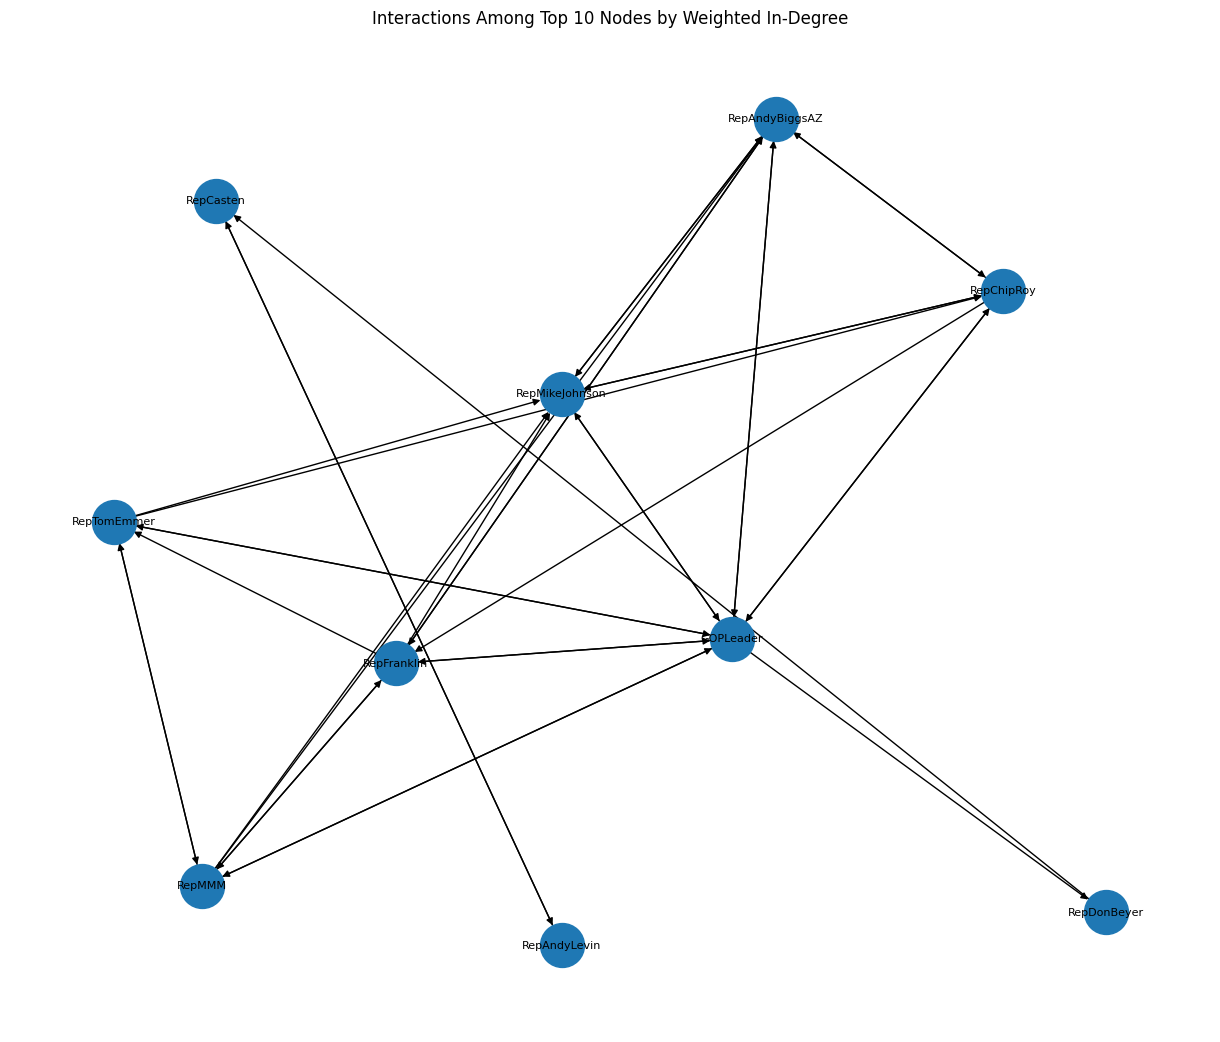

In [10]:


top_nodes = [node for node, score in top_in]

H = G.subgraph(top_nodes)

# Create username labels
labels = {
    node: username_list[int(node)]
    for node in H.nodes()
}

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(H, seed=42)

nx.draw(
    H,
    pos,
    labels=labels,
    node_size=1000,
    font_size=8,
    arrows=True
)

plt.title("Interactions Among Top 10 Nodes by Weighted In-Degree")
plt.show()

In [11]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

density = nx.density(G)
print("Network density:", density)

avg_in_degree = sum(dict(G.in_degree()).values()) / G.number_of_nodes()
avg_out_degree = sum(dict(G.out_degree()).values()) / G.number_of_nodes()

print("Average in-degree:", avg_in_degree)
print("Average out-degree:", avg_out_degree)

Number of nodes: 475
Number of edges: 13289
Network density: 0.05902287363979569
Average in-degree: 27.97684210526316
Average out-degree: 27.97684210526316
